## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Dataset

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## 3. Initial Data Exploration

Check for missing values, duplicate rows, and get summary statistics before doing any preprocessing.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


## 4. Exploratory Data Analysis (EDA)

Visualize the target variable and its relationship with key features before modeling.

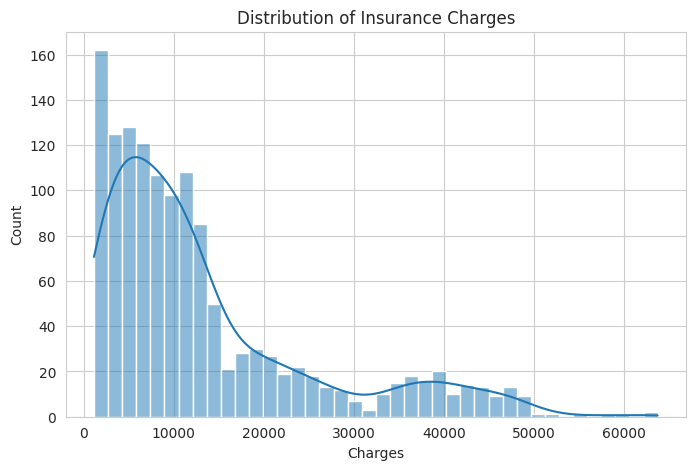

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True, bins=40)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.show()

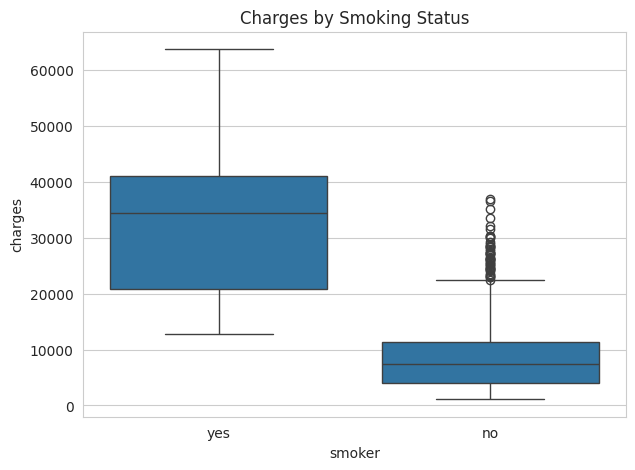

In [8]:
plt.figure(figsize=(7,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')
plt.show()

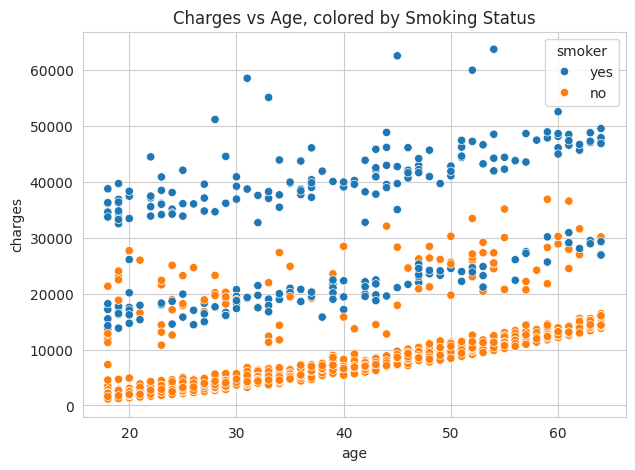

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Charges vs Age, colored by Smoking Status')
plt.show()

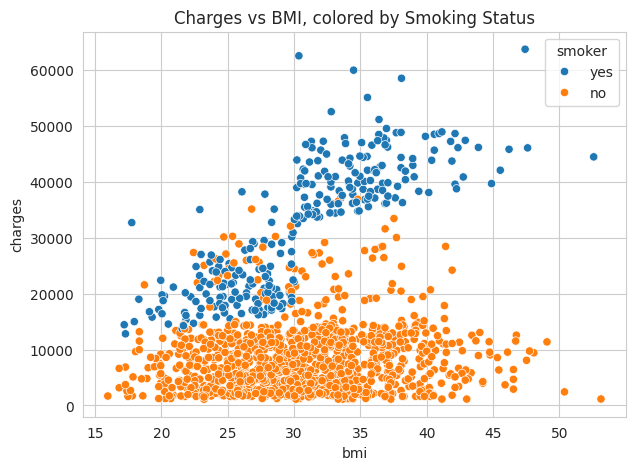

In [10]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('Charges vs BMI, colored by Smoking Status')
plt.show()

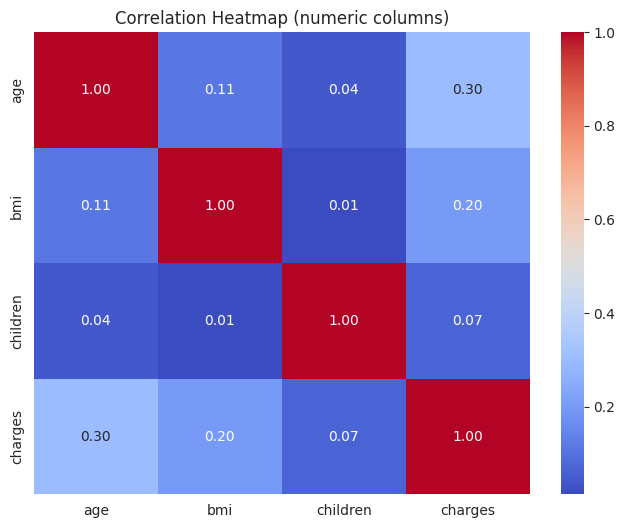

In [11]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (numeric columns)')
plt.show()

**Observation:** Smoking status visibly separates two distinct clusters of charges, and age shows a positive trend within each cluster. This suggests `smoker` and `age` will likely be important features for the model.

## 5. Encode Categorical Variables

- `sex` and `smoker` are binary → label encode as 0/1.
- `region` has 4 unrelated categories (no natural order) → one-hot encode.

In [12]:
df_encoded = df.copy()

df_encoded['sex'] = df_encoded['sex'].map({'male': 0, 'female': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


## 6. Define Features (X) and Target (y)

In [13]:
X = df_encoded.drop(columns='charges')
y = df_encoded['charges']

print("Features:", list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
X shape: (1338, 8) | y shape: (1338,)


## 7. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (1070, 8) | Test size: (268, 8)


## 8. Train a Baseline Decision Tree Regressor

Start with a constrained tree (`max_depth=4`) to get a readable baseline before tuning.

In [15]:
dt = DecisionTreeRegressor(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

## 9. Evaluate the Baseline Model

For regression, accuracy doesn't apply — instead we use:
- **MAE** (Mean Absolute Error): average absolute difference between predicted and actual charges.
- **MSE / RMSE**: penalizes larger errors more heavily.
- **R² score**: proportion of variance in charges explained by the model (closer to 1 is better).

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 2,697.77
MSE  : 21,093,484.00
RMSE : 4,592.76
R2   : 0.8641


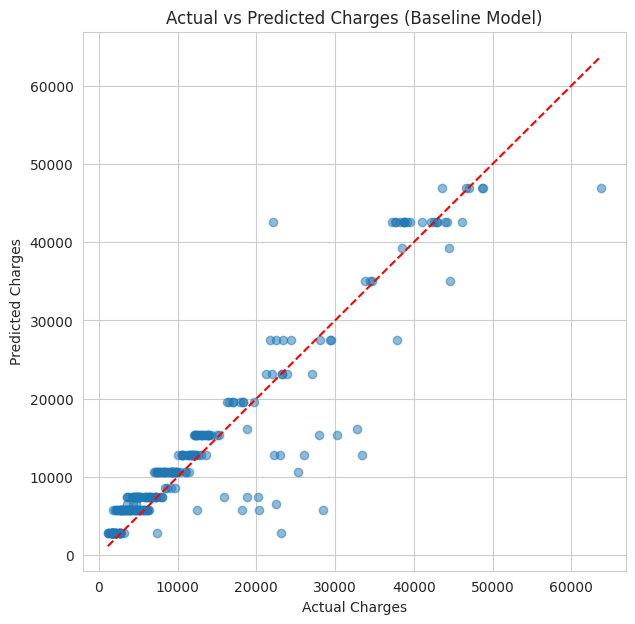

In [17]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges (Baseline Model)')
plt.show()

## 10. Hyperparameter Tuning with GridSearchCV

Search over `max_depth`, `min_samples_split`, and `min_samples_leaf` using 5-fold cross-validation, optimizing for negative MSE (GridSearchCV maximizes the score, so MSE is negated).

In [18]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV RMSE:", np.sqrt(-grid.best_score_))

Best params: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV RMSE: 4801.676665868447


## 11. Evaluate the Tuned Model on the Test Set

In [19]:
best_dt = grid.best_estimator_
y_pred_tuned = best_dt.predict(X_test)

mae_t = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_t = r2_score(y_test, y_pred_tuned)

print(f"Tuned MAE  : {mae_t:,.2f}")
print(f"Tuned RMSE : {rmse_t:,.2f}")
print(f"Tuned R2   : {r2_t:.4f}")

print("\n--- Comparison ---")
print(f"Baseline -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R2: {r2:.4f}")
print(f"Tuned    -> MAE: {mae_t:,.2f} | RMSE: {rmse_t:,.2f} | R2: {r2_t:.4f}")

Tuned MAE  : 2,697.77
Tuned RMSE : 4,592.76
Tuned R2   : 0.8641

--- Comparison ---
Baseline -> MAE: 2,697.77 | RMSE: 4,592.76 | R2: 0.8641
Tuned    -> MAE: 2,697.77 | RMSE: 4,592.76 | R2: 0.8641


## 12. Feature Importance

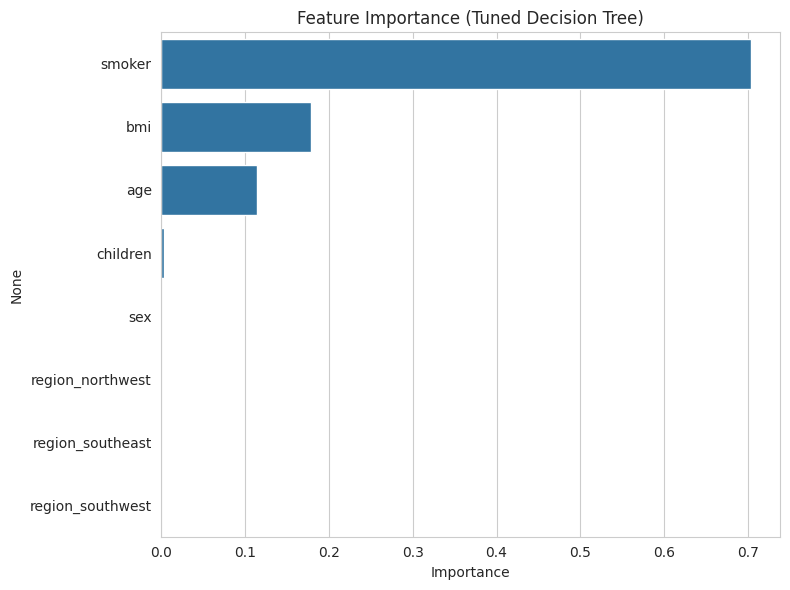

,0
smoker,0.703212
bmi,0.178707
age,0.114492
children,0.003589
sex,0.000000
region_northwest,0.000000
region_southeast,0.000000
region_southwest,0.000000


In [20]:
importances = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance (Tuned Decision Tree)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances

## 13. Visualize the Decision Tree (Top 3 Levels)

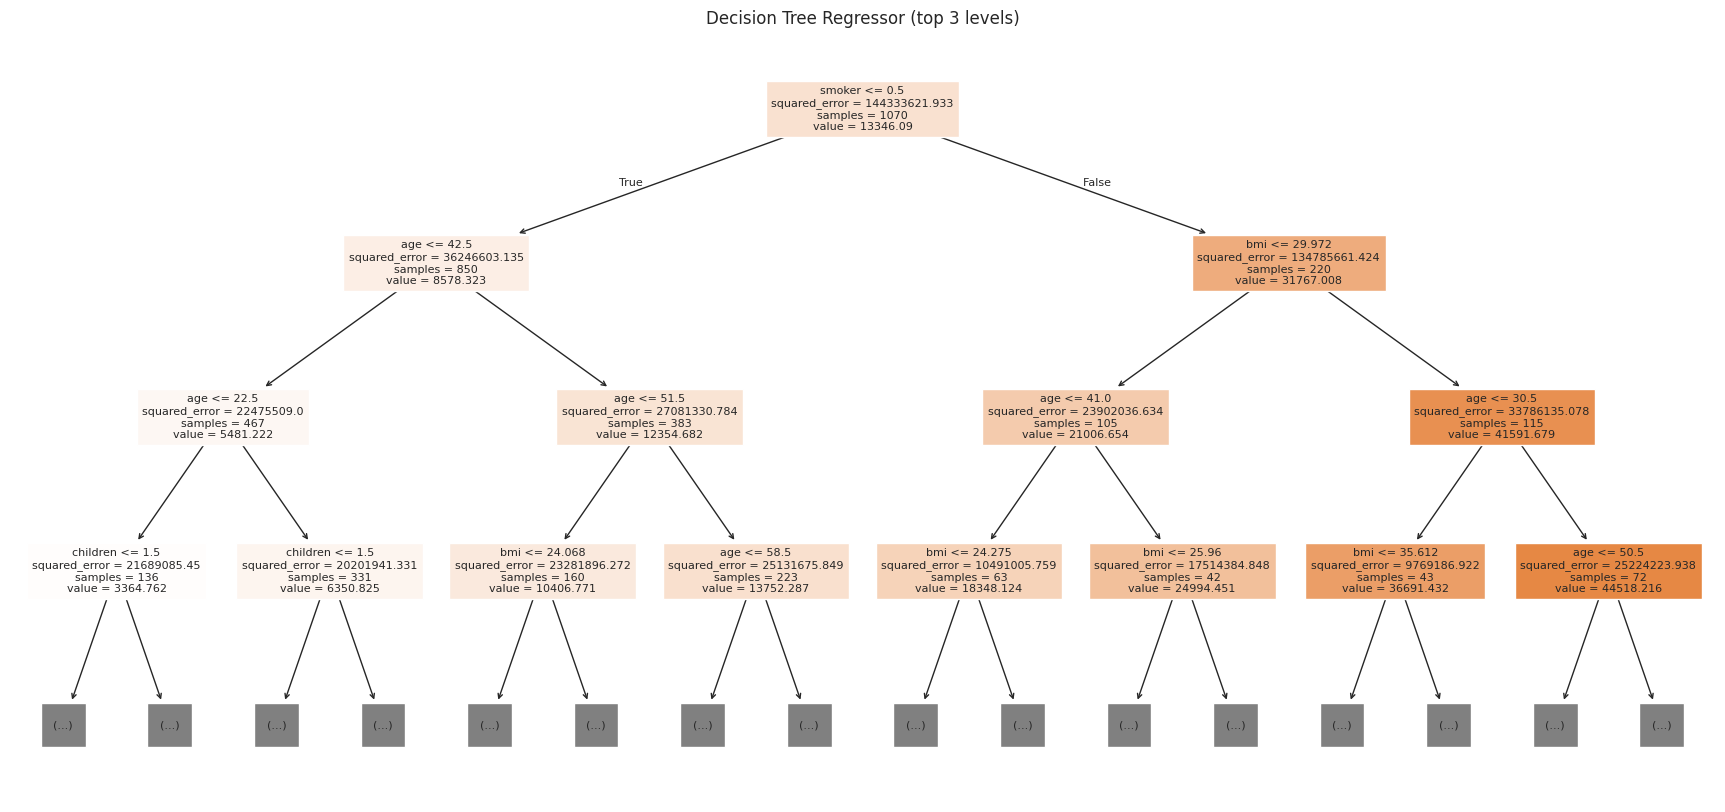

In [21]:
plt.figure(figsize=(22,10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Regressor (top 3 levels)")
plt.show()

## 14. Conclusion

A Decision Tree Regressor was trained to predict medical insurance charges. Key takeaways:

- **Smoking status** and **age** are, as expected from the EDA, the most important predictors of insurance charges.
- Hyperparameter tuning with `GridSearchCV` improved generalization over the unconstrained/baseline tree by controlling `max_depth`, `min_samples_split`, and `min_samples_leaf`, reducing overfitting.
- The R² score on the test set indicates how much of the variance in charges the model explains — values closer to 1 indicate a strong fit; this can be compared against a Random Forest or Gradient Boosting model in future work for further improvement.